In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("Raw_Data.xlsx")

df.head()

,Customer_ID,Name,Age,City,Purchase_Amount
0,101,Rahul,25.0,Hyderabad,1200
1,102,Priya,28.0,Chennai,1500
2,103,Kiran,NaN,Bangalore,1800
3,104,Sneha,30.0,Hyderabad,2200
4,105,Arjun,27.0,NaN,1700


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      15 non-null     int64  
 1   Name             15 non-null     object 
 2   Age              12 non-null     float64
 3   City             14 non-null     object 
 4   Purchase_Amount  15 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 732.0+ bytes


In [6]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Age,3
City,1
Purchase_Amount,0


In [7]:
# Fill missing Age values with the average age
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill missing City values with 'Unknown'
df["City"] = df["City"].fillna("Unknown")

# Check again
df.isnull().sum()

,0
Customer_ID,0
Name,0
Age,0
City,0
Purchase_Amount,0


In [8]:
print("Duplicates Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 1
Duplicates After: 0


In [9]:
# Convert text to proper case
df["Name"] = df["Name"].str.title()
df["City"] = df["City"].str.title()

# Display updated data
df.head()

,Customer_ID,Name,Age,City,Purchase_Amount
0,101,Rahul,25.0,Hyderabad,1200
1,102,Priya,28.0,Chennai,1500
2,103,Kiran,28.5,Bangalore,1800
3,104,Sneha,30.0,Hyderabad,2200
4,105,Arjun,27.0,Unknown,1700


In [10]:
print("Summary Statistics")
print(df.describe())

print("\nCustomers by City")
print(df["City"].value_counts())

Summary Statistics
       Customer_ID        Age  Purchase_Amount
count      14.0000  14.000000        14.000000
mean      107.5000  28.750000      1928.571429
std         4.1833   2.826727       453.072539
min       101.0000  25.000000      1200.000000
25%       104.2500  27.250000      1625.000000
50%       107.5000  28.500000      1950.000000
75%       110.7500  29.750000      2275.000000
max       114.0000  35.000000      2600.000000

Customers by City
City
Hyderabad    5
Chennai      4
Bangalore    4
Unknown      1
Name: count, dtype: int64


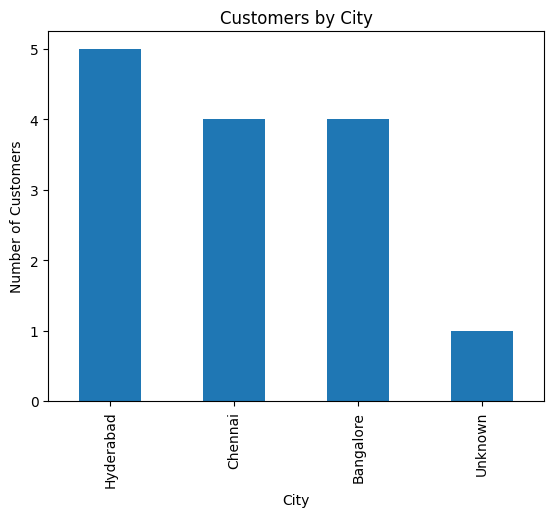

In [11]:
df["City"].value_counts().plot(kind="bar")

plt.title("Customers by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.show()

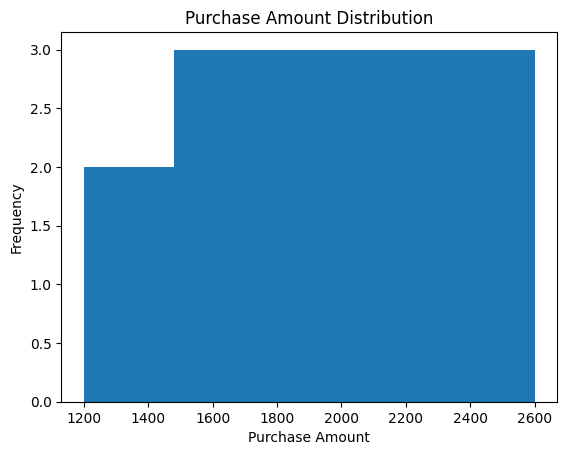

In [12]:
plt.hist(df["Purchase_Amount"], bins=5)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")

plt.show()

In [13]:
df.to_excel("Cleaned_Data.xlsx", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [14]:
report = pd.DataFrame({
    "Total Customers": [len(df)],
    "Average Age": [round(df["Age"].mean(), 2)],
    "Average Purchase Amount": [round(df["Purchase_Amount"].mean(), 2)],
    "Unique Cities": [df["City"].nunique()]
})

report.to_excel("Automated_Report.xlsx", index=False)

print(report)
print("Automated report generated successfully!")

   Total Customers  Average Age  Average Purchase Amount  Unique Cities
0               14        28.75                  1928.57              4
Automated report generated successfully!
